# Startup data: EDA and corrected cleaning

Source: [Kaggle Crunchbase dataset](https://www.kaggle.com/datasets/yanmaksi/big-startup-secsees-fail-dataset-from-crunchbase).

Run this notebook first to recreate `cleaned_startup_data.csv`. The original EDA's binary task is preserved: closed = 0, acquired = 1. Operating companies have unresolved outcomes and IPO companies are outside this particular comparison; neither is treated as failure.

Corrections: parse funding as numeric instead of dropping it as high-cardinality text; retain country and the first listed category; remove the repeated date-conversion step; defer median imputation, encoding, and scaling to the training pipelines. Missing values in the exported CSV are intentional.

In [1]:
from pathlib import Path
import io
import urllib.request
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

data_path = Path("data/big_startup_secsees_dataset.csv")
if not data_path.exists():
    url = "https://www.kaggle.com/api/v1/datasets/download/yanmaksi/big-startup-secsees-fail-dataset-from-crunchbase"
    archive_bytes = urllib.request.urlopen(url, timeout=90).read()
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        data_path.parent.mkdir(exist_ok=True)
        data_path.write_bytes(archive.read("big_startup_secsees_dataset.csv"))

df = pd.read_csv(data_path)
print("Rows and columns:", df.shape)
display(df.head())

Matplotlib is building the font cache; this may take a moment.


Rows and columns: (66368, 14)


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


,missing_values
permalink,0
name,1
homepage_url,5058
category_list,3148
funding_total_usd,0
status,0
country_code,6958
state_code,8547
region,8030
city,8028


,startups
status,
operating,53034
closed,6238
acquired,5549
ipo,1547


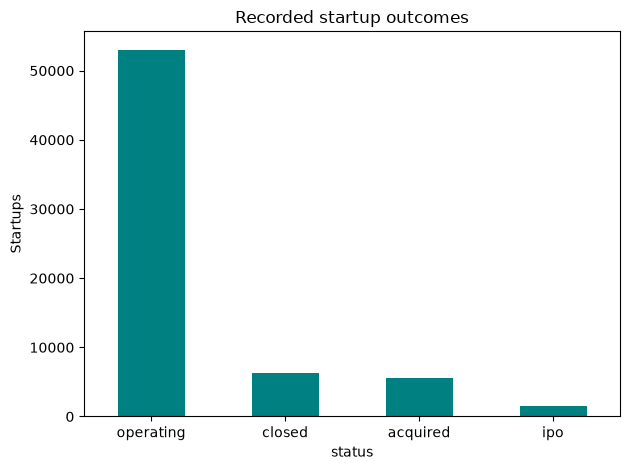

In [2]:
df.info()
display(df.isna().sum().rename("missing_values").to_frame())
display(df["status"].value_counts().rename("startups").to_frame())
df["status"].value_counts().plot.bar(color="teal", rot=0)
plt.title("Recorded startup outcomes")
plt.ylabel("Startups")
plt.tight_layout()
plt.show()

In [3]:
print("Exact duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().copy()
df["status"] = df["status"].str.strip().str.lower()
assert df["permalink"].notna().all()
assert df["permalink"].is_unique

df_clean = df[df["status"].isin(["acquired", "closed"])].copy()
df_clean["target"] = df_clean["status"].map({"closed": 0, "acquired": 1})
df_clean = df_clean.rename(columns={"permalink": "startup_id"})
print("Labeled startups:", len(df_clean))
print("Excluded operating startups:", df["status"].eq("operating").sum())
print("Excluded IPO startups:", df["status"].eq("ipo").sum())
display(df_clean["target"].value_counts().sort_index())

Exact duplicate rows: 0
Labeled startups: 11787
Excluded operating startups: 53034
Excluded IPO startups: 1547


target
0    6238
1    5549
Name: count, dtype: int64

## Numeric and date corrections

Unknown funding (`-`) becomes missing rather than zero. Negative funding and non-positive funding-round counts are invalid. Date years outside 1800–2015 become missing: 2015 is an explicit historical cutoff inferred from this file's funding-date distribution, not today's year. This assumes a snapshot through 2015 and should be revisited for a newer dataset. Reversed first/last funding dates are removed; founding dates later than the last funding date are treated as inconsistent. No attempt is made to guess typo corrections. Founding-after-funding is treated conservatively: it can also reflect genuine pre-incorporation funding rather than a typo.

In [4]:
funding = df_clean["funding_total_usd"].astype("string").str.replace(",", "", regex=False)
df_clean["funding_total_usd"] = pd.to_numeric(funding, errors="coerce")
df_clean.loc[df_clean["funding_total_usd"] < 0, "funding_total_usd"] = np.nan
df_clean["funding_rounds"] = pd.to_numeric(df_clean["funding_rounds"], errors="coerce")
df_clean.loc[df_clean["funding_rounds"] <= 0, "funding_rounds"] = np.nan

date_columns = ["founded_at", "first_funding_at", "last_funding_at"]
for column in date_columns:
    dates = pd.to_datetime(df_clean[column], format="%Y-%m-%d", errors="coerce")
    valid_year = dates.dt.year.between(1800, 2015)
    print(column, "invalid dates:", (df_clean[column].notna() & ~valid_year).sum())
    df_clean[column] = dates.where(valid_year)

reversed_funding = df_clean["first_funding_at"] > df_clean["last_funding_at"]
print("Reversed funding dates:", reversed_funding.sum())
df_clean.loc[reversed_funding, ["first_funding_at", "last_funding_at"]] = pd.NaT
late_founding = df_clean["founded_at"] > df_clean["last_funding_at"]
print("Founding after last funding:", late_founding.sum())
df_clean.loc[late_founding, "founded_at"] = pd.NaT

for column in date_columns:
    df_clean[column + "_year"] = df_clean[column].dt.year

founded_at invalid dates: 4
first_funding_at invalid dates: 0
last_funding_at invalid dates: 1
Reversed funding dates: 0
Founding after last funding: 411


## Modeling features

The first listed category is a simple representation of a multi-category field; it is not necessarily the company's primary category. Country is retained, while redundant detailed locations and identifying fields are omitted. `startup_id` is exported only to verify that both notebooks use the same companies in the test set; it is never a predictor.

In [5]:
df_clean["country_code"] = df_clean["country_code"].str.strip().str.upper().replace("", np.nan)
df_clean["first_category"] = df_clean["category_list"].str.split("|").str[0].str.strip().replace("", np.nan)
columns = [
    "startup_id", "funding_total_usd", "funding_rounds",
    "founded_at_year", "first_funding_at_year", "last_funding_at_year",
    "country_code", "first_category", "target"
]
df_final = df_clean[columns].sort_values("startup_id").reset_index(drop=True)
assert df_final["target"].isin([0, 1]).all()
assert df_final["startup_id"].is_unique
df_final.to_csv("cleaned_startup_data.csv", index=False)
print("Saved cleaned_startup_data.csv:", df_final.shape)
display(df_final.head())
display(df_final.isna().sum().rename("missing_before_training_imputation").to_frame())

Saved cleaned_startup_data.csv: (11787, 9)


,startup_id,funding_total_usd,funding_rounds,founded_at_year,first_funding_at_year,last_funding_at_year,country_code,first_category,target
0,/organization/1-mainstream,5000000.0,1.0,2012.0,2015.0,2015.0,USA,Apps,1
1,/organization/1000-markets,500000.0,1.0,2009.0,2009.0,2009.0,USA,Art,1
2,/organization/1000memories,2535000.0,2.0,2010.0,2010.0,2011.0,USA,Curated Web,1
3,/organization/100plus,1250000.0,2.0,2011.0,2011.0,2011.0,USA,Analytics,1
4,/organization/1010data,35000000.0,1.0,2000.0,2010.0,2010.0,USA,Software,1


,missing_before_training_imputation
startup_id,0
funding_total_usd,2085
funding_rounds,0
founded_at_year,3787
first_funding_at_year,2
last_funding_at_year,1
country_code,1951
first_category,1073
target,0


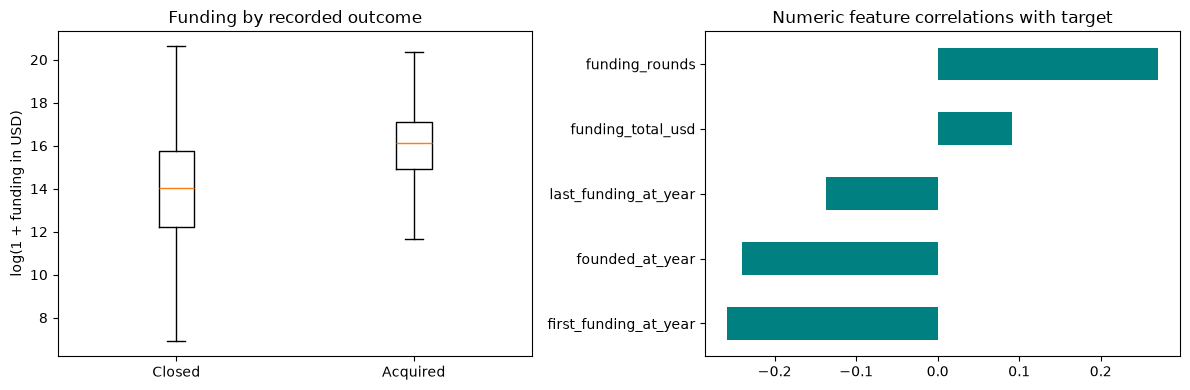

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
funding_groups = [
    np.log1p(df_final.loc[df_final["target"] == label, "funding_total_usd"].dropna())
    for label in [0, 1]
]
axes[0].boxplot(funding_groups, showfliers=False)
axes[0].set_xticks([1, 2], ["Closed", "Acquired"])
axes[0].set_ylabel("log(1 + funding in USD)")
axes[0].set_title("Funding by recorded outcome")
correlations = df_final.select_dtypes(include="number").corr()["target"].drop("target")
correlations.sort_values().plot.barh(ax=axes[1], color="teal")
axes[1].set_title("Numeric feature correlations with target")
plt.tight_layout()
plt.show()

## Interpretation limit

These are retrospective outcome classifiers, not time-to-failure models. Funding totals and last funding dates describe the recorded company history and are not guaranteed to predate acquisition or closure. The dataset lacks the outcome dates and fixed observation window needed to establish prospective survival performance. A random holdout measures this historical classification task; deployment on operating startups requires separate validation and features measured before the prediction date.